<a href="https://colab.research.google.com/github/SalvatoreSisay/Challenge-Telecome-X/blob/main/Challenge_TelecomX_LA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Telecom X — Análisis de Evasión de Clientes 🕵️

**Objetivo**: Analizar un suceso que enfrenta la empresa sobre la evasión de clientes parte del proyecto **"Churn de Clientes"** a partir de datos demográficos, de servicios y de facturación, identificando patrones que puedan apoyar estrategias de retención.

Fuente de datos: archivo JSON obtenido en el repositorio oficial del challenge (que son datos en crudo con formato JSON).

#📌 Extracción

✅ Cargar los datos directamente desde la API utilizando Python y convertir los datos en un DataFrame de Pandas.

In [2]:
import pandas as pd
url = '/content/TelecomX_Data.json'
#El url se puede remplazar usando el link directo del repositorio o en mi caso
#para uso mas practico cargar la ruta del archivo dentro del notebook.
#link del url del repo "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
df = pd.read_json(url)
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#🔧 Transformación

✅ Despues de haber extraído los datos, es fundamental comprender la estructura del dataset asi que en esta etapa identificaremos qué variables son más relevantes para el análisis de evasión de clientes.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


## Normalizacion del Json

In [5]:
df_normalized = pd.json_normalize(df.to_dict(orient="records"))
df_normalized.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [6]:
df_normalized.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

A partir del diccionario de datos dado en el repositorio (adjunto link de la url "https://github.com/ingridcristh/challenge2-data-science-LATAM/blob/main/TelecomX_diccionario.md"), se seleccionaron las variables más relevantes para el análisis de evasión de clientes, teniendo la prioridad en la información sobre contratos, antigüedad y cargos.

## Comprobación de incoherencias en los datos.
Limpieza, tratamiento y verificación de incoherencias.

In [8]:
dup_customer = df_normalized['customerID'].duplicated().sum()
#Verificacion basica de duplicados
dup_customer

np.int64(0)

In [9]:
df_normalized['Churn'] = df_normalized['Churn'].astype(str).str.strip()
#Normalizo
df_normalized = df_normalized[df_normalized['Churn'].isin(['Yes', 'No'])].copy()
#Filtrar valores validos de "Yes/No"
df_normalized['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [10]:

# Ingresa como texto y lo convertimos a numérico para análisis cuantitativo
df_normalized['account.Charges.Total'] = pd.to_numeric(df_normalized['account.Charges.Total'], errors='coerce')

# Asumimos total gastado = 0; sin historial de cobro acumulado
mask_tenure0 = df_normalized['customer.tenure'] == 0
df_normalized.loc[mask_tenure0, 'account.Charges.Total'] = 0

# Revisión de nulos remanentes
df_normalized['account.Charges.Total'].isna().sum()

np.int64(0)

In [11]:
# Verificacion de los tipos consistentes y sin nulos en variables clave
df_normalized.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7043 non-null   object 
 1   Churn                      7043 non-null   object 
 2   customer.gender            7043 non-null   object 
 3   customer.SeniorCitizen     7043 non-null   int64  
 4   customer.Partner           7043 non-null   object 
 5   customer.Dependents        7043 non-null   object 
 6   customer.tenure            7043 non-null   int64  
 7   phone.PhoneService         7043 non-null   object 
 8   phone.MultipleLines        7043 non-null   object 
 9   internet.InternetService   7043 non-null   object 
 10  internet.OnlineSecurity    7043 non-null   object 
 11  internet.OnlineBackup      7043 non-null   object 
 12  internet.DeviceProtection  7043 non-null   object 
 13  internet.TechSupport       7043 non-null   object 
 1

Se verificaron los datos y no se presentaron valores nulos y hay inexistencia de datos duplicados y se corrigieron errores de formato en variables numéricas y se validaron los valores de la variable Churn, asegurando que los datos estén listos para el análisis exploratorio.

### Columna de cuentas diarias (Opcional)

Se utilizara la facturación mensual para calcular el valor diario, proporcionando una visión más detallada del comportamiento de los clientes a lo largo del tiempo.

In [12]:
df_normalized['Cuentas_Diarias'] = df_normalized['account.Charges.Monthly'] / 30

df_normalized[['account.Charges.Monthly', 'Cuentas_Diarias']].head()

,account.Charges.Monthly,Cuentas_Diarias
0,65.6,2.186667
1,59.9,1.996667
2,73.9,2.463333
3,98.0,3.266667
4,83.9,2.796667


### Estandarización y transformación de datos (opcional)

Se hara transformacion de los datos para que sean mas comprensibles, consistentes y adecuados para el analisis ademas de traducir o renombrar columnas y datos

In [13]:
df_normalized['Churn_bin'] = df_normalized['Churn'].map({'No': 0, 'Yes': 1})
df_normalized['PaperlessBilling_bin'] = df_normalized['account.PaperlessBilling'].map({'No': 0, 'Yes': 1})

df_normalized[['Churn','Churn_bin','account.PaperlessBilling','PaperlessBilling_bin']].head()

,Churn,Churn_bin,account.PaperlessBilling,PaperlessBilling_bin
0,No,0,Yes,1
1,No,0,No,0
2,Yes,1,Yes,1
3,Yes,1,Yes,1
4,Yes,1,Yes,1


#📊 Carga y análisis

✅ Ya con los datos tratados ahora realizaremos el analisis exploratorio de los datos, empezando con lo basico para tener un panorama de lo que nos vamos a encontrar lo cual seria un analisis descriptivo calculando métricas como media, mediana, desviación estándar y otras medidas que ayuden a comprender mejor la distribución y el comportamiento de los clientes.

In [15]:
df_normalized[['customer.tenure','account.Charges.Monthly','account.Charges.Total','Cuentas_Diarias']].describe()

,customer.tenure,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304,2.158723
std,24.559481,30.090047,2266.794470,1.003002
min,0.000000,18.250000,0.000000,0.608333
25%,9.000000,35.500000,398.550000,1.183333
50%,29.000000,70.350000,1394.550000,2.345000
75%,55.000000,89.850000,3786.600000,2.995000
max,72.000000,118.750000,8684.800000,3.958333


## Distribución de evasión

In [16]:
churn_pct = df_normalized['Churn'].value_counts(normalize=True) * 100
churn_pct

,proportion
Churn,
No,73.463013
Yes,26.536987


Se logra apreciar la proporción de clientes que permanecen contra los que abandonan.

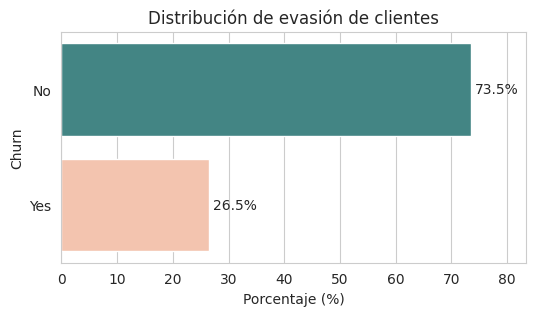

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
sns.set_style("whitegrid")

# Convert the churn_pct Series to a DataFrame
churn_df = churn_pct.reset_index()
churn_df.columns = ['Churn', 'Porcentaje']

plt.figure(figsize=(6,3))
ax = sns.barplot(
    data=churn_df,
    y='Churn',
    x='Porcentaje',
    orient='h',
    hue='Churn',
    palette={
        'No': '#38908F',
        'Yes': '#FFBFA3'
    },
    legend=False
)

plt.title('Distribución de evasión de clientes')
plt.xlabel('Porcentaje (%)')
plt.ylabel('Churn')

# Etiquetas
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.xlim(0, churn_df['Porcentaje'].max() + 10)
plt.show()

Se puede observar que aproximadamente el 73.5% de los clientes no han abandonado el servicio, mientras que un 26.5% sí lo han hecho. Esto nos da una idea clara de la proporción de clientes que retiene la empresa y los que se van.

## Recuento de evasión por variables categóricas

exploraremos cómo se distribuye la evasión según variables categóricas, como género, tipo de contrato, método de pago, entre otras, este análisis puede revelar patrones interesantes.

#### **Churn según tipo de contrato**

In [25]:
churn_by_contract = (
    df_normalized
    .groupby('account.Contract')['Churn']
    .value_counts(normalize=True)
    .mul(100)
    .rename('percentage')
    .reset_index()
)
churn_by_contract

,account.Contract,Churn,percentage
0,Month-to-month,No,57.290323
1,Month-to-month,Yes,42.709677
2,One year,No,88.730482
3,One year,Yes,11.269518
4,Two year,No,97.168142
5,Two year,Yes,2.831858


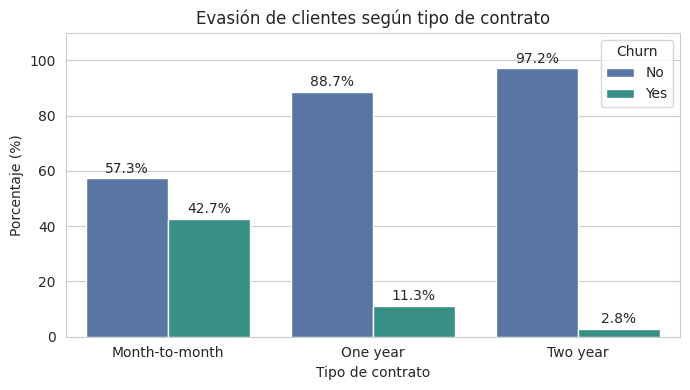

In [27]:
plt.figure(figsize=(7,4))

# Define the order for the contract types
order_contract = ['Month-to-month', 'One year', 'Two year']

ax = sns.barplot(
    data=churn_by_contract,
    x='account.Contract',
    y='percentage',
    hue='Churn',
    order=order_contract,
    palette={
        'No': '#4C72B0',
        'Yes': '#2A9D8F'
    }
)

plt.title('Evasión de clientes según tipo de contrato')
plt.xlabel('Tipo de contrato')
plt.ylabel('Porcentaje (%)')

# etiquetas
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=2)

plt.ylim(0, 110)
plt.legend(title='Churn', loc='upper right')
plt.tight_layout()
plt.show()

Este gráfico nos revela información clave:

Contratos mes a mes (Month-to-month): Tienen la tasa de evasión más alta, con aproximadamente el 42.7% de los clientes abandonando el servicio.
Contratos de un año (One year): Muestran una tasa de evasión considerablemente menor, alrededor del 11.3%.
Contratos de dos años (Two year): Presentan la tasa de evasión más baja, con solo un 2.8%.

Esto sugiere que los contratos a largo plazo, especialmente los de dos años, son más efectivos para retener a los clientes.

#### **Churn según género**

In [28]:
churn_by_gender = (
    df_normalized
    .groupby('customer.gender')['Churn']
    .value_counts(normalize=True)
    .mul(100)
    .rename('percentage')
    .reset_index()
)
churn_by_gender

,customer.gender,Churn,percentage
0,Female,No,73.079128
1,Female,Yes,26.920872
2,Male,No,73.839662
3,Male,Yes,26.160338


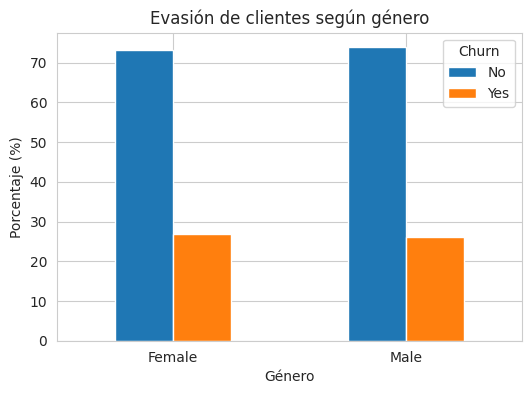

In [29]:

pivot_gender = churn_by_gender.pivot(index='customer.gender', columns='Churn', values='percentage')
pivot_gender.plot(kind='bar', figsize=(6,4), rot=0)
plt.title('Evasión de clientes según género')
plt.xlabel('Género')
plt.ylabel('Porcentaje (%)')
plt.show()

 #### **Churn según método de pago**

In [30]:
churn_by_payment = (
    df_normalized
    .groupby('account.PaymentMethod')['Churn']
    .value_counts(normalize=True)
    .mul(100)
    .rename('percentage')
    .reset_index()
)
churn_by_payment


,account.PaymentMethod,Churn,percentage
0,Bank transfer (automatic),No,83.290155
1,Bank transfer (automatic),Yes,16.709845
2,Credit card (automatic),No,84.756899
3,Credit card (automatic),Yes,15.243101
4,Electronic check,No,54.714588
5,Electronic check,Yes,45.285412
6,Mailed check,No,80.893300
7,Mailed check,Yes,19.106700


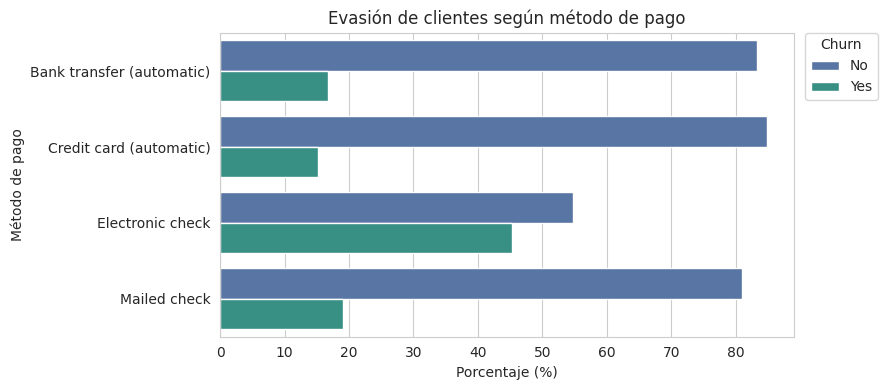

In [31]:
plt.figure(figsize=(9,4))

ax = sns.barplot(
    data=churn_by_payment,
    y='account.PaymentMethod',
    x='percentage',
    hue='Churn',
    palette={'No': '#4C72B0', 'Yes': '#2A9D8F'}
)

plt.title('Evasión de clientes según método de pago')
plt.xlabel('Porcentaje (%)')
plt.ylabel('Método de pago')

plt.legend(title='Churn', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.show()

 En general, el tipo de contrato y el método de pago tienden a mostrar mayores diferencias en churn.

## Conteo de evasión por variables numéricas

#📄Informe final